# Лабораторная работа №4

## Линейные модели, SVM и деревья решений


# Описание задания

Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений.

Необходимо выполнить следующие действия:

- выбрать датасет для решения задачи классификации или регрессии;
- при необходимости обработать пропуски и закодировать категориальные признаки;
- с использованием `train_test_split` разделить выборку на обучающую и тестовую;
- обучить одну линейную модель;
- обучить SVM;
- обучить дерево решений;
- оценить качество моделей с помощью двух подходящих метрик;
- сравнить качество полученных моделей;
- построить график важности признаков для дерева решений;
- визуализировать дерево решений или вывести правила дерева решений в текстовом виде.

В работе используется датасет **Titanic**. Решается задача бинарной классификации: необходимо предсказать, выжил пассажир (`Survived = 1`) или нет (`Survived = 0`).


# Текст программы

## Импорт библиотек


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

%matplotlib inline

sns.set_theme(style='ticks')

# Загрузка и первичный анализ данных


In [2]:
data = pd.read_csv('../2/titanic.csv')

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.shape

(891, 12)

In [4]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Text(0.5, 1.0, 'Распределение целевого признака Survived')

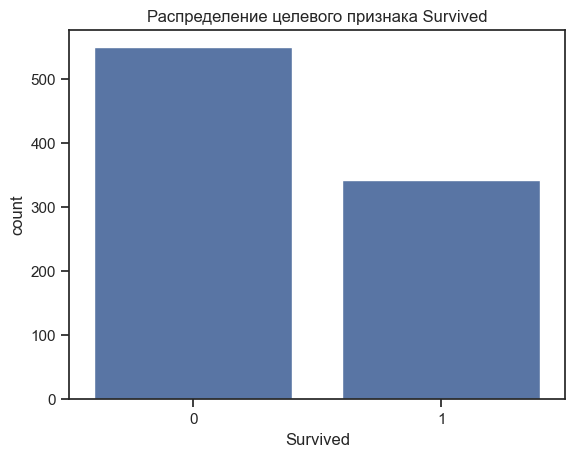

In [7]:
sns.countplot(x='Survived', data=data)
plt.title('Распределение целевого признака Survived')

# Подготовка данных

Обработаем пропуски и подготовим признаки:

- `Age` заполним медианой;
- `Embarked` заполним наиболее частым значением;
- `Cabin` заполним категорией `Unknown`;
- из `Cabin` выделим первую букву каюты (`CabinDeck`);
- удалим признаки `PassengerId`, `Name`, `Ticket`, `Cabin`;
- категориальные признаки закодируем с помощью one-hot encoding.


In [8]:
data_prepared = data.copy()

data_prepared['Age'] = data_prepared['Age'].fillna(data_prepared['Age'].median())
data_prepared['Embarked'] = data_prepared['Embarked'].fillna(data_prepared['Embarked'].mode()[0])
data_prepared['Cabin'] = data_prepared['Cabin'].fillna('Unknown')
data_prepared['CabinDeck'] = data_prepared['Cabin'].str[0]

data_prepared.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
CabinDeck      0
dtype: int64

In [9]:
model_data = data_prepared.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

model_data = pd.get_dummies(
    model_data,
    columns=['Sex', 'Embarked', 'CabinDeck'],
    drop_first=False
)

model_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U
0,0,3,22.0,1,0,7.2500,False,True,False,False,True,False,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True,False,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True,False,False,True,False,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,False,True,False,False,True,False,False,False,False,False,False,False,False,True


In [10]:
model_data.shape

(891, 20)

# Разделение выборки на обучающую и тестовую

Целевой признак - `Survived`. Используем стратифицированное разделение, чтобы сохранить соотношение классов в обучающей и тестовой выборках.


In [11]:
X = model_data.drop(columns=['Survived'])
y = model_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((668, 19), (223, 19), (668,), (223,))

In [12]:
pd.DataFrame({
    'train': y_train.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True)
})

,train,test
Survived,,
0,0.616766,0.61435
1,0.383234,0.38565


# Масштабирование числовых признаков

Логистическая регрессия и SVM чувствительны к масштабу признаков, поэтому числовые признаки масштабируем с помощью `StandardScaler`. Параметры масштабирования рассчитываются только на обучающей выборке.


In [13]:
numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U
486,-1.579334,0.419907,0.536677,-0.451483,1.240397,True,False,False,False,True,False,False,True,False,False,False,False,False,False
238,-0.376375,-0.813532,-0.464720,-0.451483,-0.436028,False,True,False,False,True,False,False,False,False,False,False,False,False,True
722,-0.376375,0.342817,-0.464720,-0.451483,-0.383310,False,True,False,False,True,False,False,False,False,False,False,False,False,True
184,0.826584,-1.969882,-0.464720,1.951631,-0.192999,True,False,False,False,True,False,False,False,False,False,False,False,False,True
56,-0.376375,-0.659352,-0.464720,-0.451483,-0.436028,True,False,False,False,True,False,False,False,False,False,False,False,False,True


# Обучение моделей

Обучим три модели:

- логистическую регрессию как линейную модель для классификации;
- SVM;
- дерево решений.


## Логистическая регрессия


In [14]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0])

## SVM


In [15]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0])

## Дерево решений

Для дерева решений используем ограничение глубины, чтобы дерево было проще интерпретировать.


In [16]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

# Оценка качества моделей

Для задачи классификации используем две основные метрики:

- `accuracy` - доля правильных ответов;
- `f1` - гармоническое среднее precision и recall.

Дополнительно рассчитаем `precision` и `recall`, чтобы лучше интерпретировать результаты.


In [17]:
def get_classification_metrics(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame([
    get_classification_metrics(y_test, log_reg_pred, 'LogisticRegression'),
    get_classification_metrics(y_test, svm_pred, 'SVM'),
    get_classification_metrics(y_test, tree_pred, 'DecisionTree')
])

metrics_df

,model,accuracy,precision,recall,f1
0,LogisticRegression,0.780269,0.717647,0.709302,0.713450
1,SVM,0.816143,0.784810,0.720930,0.751515
2,DecisionTree,0.780269,0.849057,0.523256,0.647482


In [18]:
print('LogisticRegression')
print(classification_report(y_test, log_reg_pred))

print('SVM')
print(classification_report(y_test, svm_pred))

print('DecisionTree')
print(classification_report(y_test, tree_pred))

LogisticRegression
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       137
           1       0.72      0.71      0.71        86

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223

SVM
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       137
           1       0.78      0.72      0.75        86

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.81      0.82      0.81       223

DecisionTree
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       137
           1       0.85      0.52      0.65        86

    accuracy                           0.78       223
   macro avg       0.80      0.73      0.74       223
weighted avg       0.79      0.78     

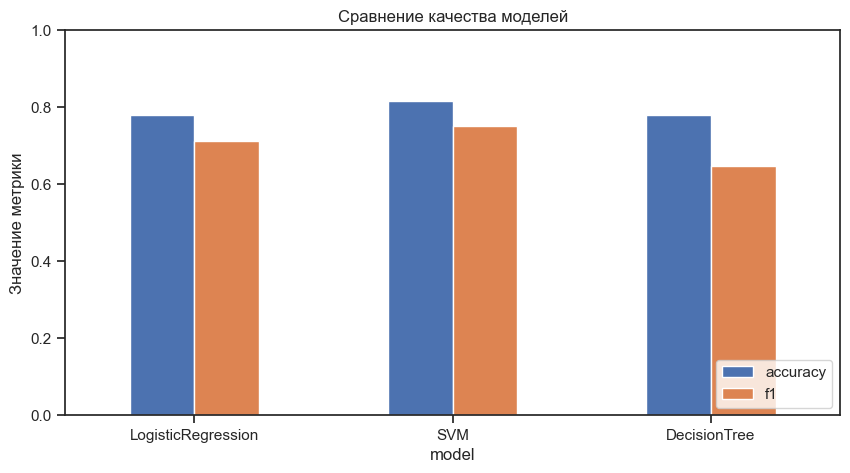

In [19]:
metrics_plot = metrics_df.set_index('model')

metrics_plot[['accuracy', 'f1']].plot(kind='bar', figsize=(10, 5))
plt.ylim(0, 1)
plt.title('Сравнение качества моделей')
plt.ylabel('Значение метрики')
plt.xticks(rotation=0)
plt.legend(loc='lower right')

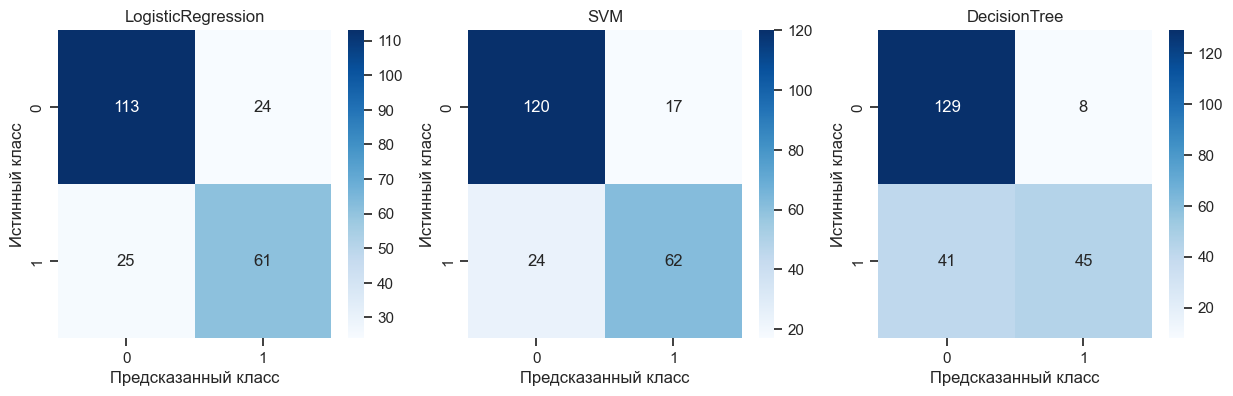

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for current_ax, y_pred, title in zip(
    ax,
    [log_reg_pred, svm_pred, tree_pred],
    ['LogisticRegression', 'SVM', 'DecisionTree']
):
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=current_ax)
    current_ax.set_title(title)
    current_ax.set_xlabel('Предсказанный класс')
    current_ax.set_ylabel('Истинный класс')

# Важность признаков в дереве решений

Дерево решений позволяет оценить важность признаков через атрибут `feature_importances_`.


In [21]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances.head(15)

,feature,importance
5,Sex_female,0.574956
1,Age,0.149617
0,Pclass,0.126396
18,CabinDeck_U,0.078321
4,Fare,0.058507
2,SibSp,0.011375
3,Parch,0.000829
6,Sex_male,0.000000
7,Embarked_C,0.000000
8,Embarked_Q,0.000000


Text(0, 0.5, 'Признак')

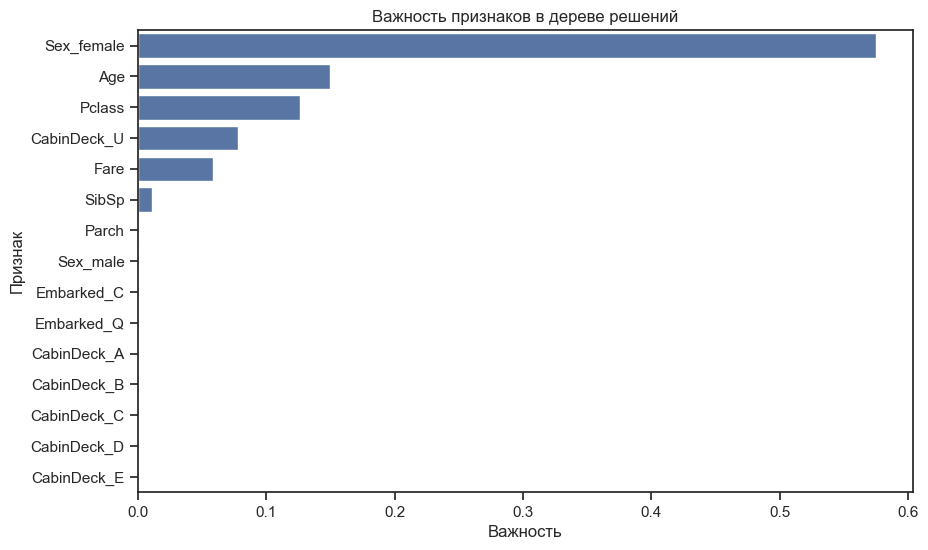

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importances.head(15),
    x='importance',
    y='feature'
)

plt.title('Важность признаков в дереве решений')
plt.xlabel('Важность')
plt.ylabel('Признак')

# Правила дерева решений

Выведем правила дерева решений в текстовом виде.


In [23]:
tree_rules = export_text(tree_model, feature_names=list(X_train.columns))

print(tree_rules)

|--- Sex_female <= 0.50
|   |--- CabinDeck_U <= 0.50
|   |   |--- Age <= 17.50
|   |   |   |--- class: 1
|   |   |--- Age >  17.50
|   |   |   |--- Fare <= 7.85
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  7.85
|   |   |   |   |--- class: 0
|   |--- CabinDeck_U >  0.50
|   |   |--- Age <= 3.50
|   |   |   |--- SibSp <= 2.00
|   |   |   |   |--- class: 1
|   |   |   |--- SibSp >  2.00
|   |   |   |   |--- class: 0
|   |   |--- Age >  3.50
|   |   |   |--- Fare <= 54.25
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  54.25
|   |   |   |   |--- class: 0
|--- Sex_female >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- Age <= 56.00
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  56.00
|   |   |   |   |--- class: 0
|   |   |--- Fare >  28.86
|   |   |   |--- Parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- Parch >  1.50
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 7.89
|   |   |   |--- Age <= 29.25
| 

# Выводы

В ходе лабораторной работы была решена задача классификации на датасете **Titanic**.

Были выполнены следующие действия:

- проведена подготовка данных: заполнены пропуски и закодированы категориальные признаки;
- выборка разделена на обучающую и тестовую с помощью `train_test_split`;
- числовые признаки масштабированы для логистической регрессии и SVM;
- обучены три модели: `LogisticRegression`, `SVC` и `DecisionTreeClassifier`;
- качество моделей оценено с помощью метрик `accuracy` и `f1`;
- построено сравнение качества моделей;
- построен график важности признаков для дерева решений;
- правила дерева решений выведены в текстовом виде.
